# `BAM` Alignment Annotation File Comparison

## Purpose: 

Figure out whether the annotation files used for alignment between the newest `BAM` files of `eCLIP` and `shRNA-KD` are the same. 

## Summary of Results

* eCLIP is the only assay that has files that are called “unfiltered alignments” (maybe these include unmapped reads). Either way, I’ll look into the unmapped reads stuff soon. 
* All the below statements are looking at alignments and not transcript alignments. 
* shRNA data that is labeled with ENCODE4 v1.2.1 GRCh38 V29 is the most comprehensive dataset. 
    * It contains all previous RBPs in hg19 and new ones all analyzed together. 
* 142 RBPs in eCLIP are uniquely analyzed in "no genome annotation" (they don't specify the genome annotation). 
* 18 RBPs in eCLIP are uniquely analyzed with V29. 
* The versions of STAR used are not the same for all files between eCLIP and shRNA. 
* There are 31 RBPs that have eCLIP data but no shRNA. 
    * Many of the 31 have CRISPR RNA instead of shRNA.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.width', 10000000)

In [2]:
eclip = pd.read_csv("eclip_metadata.tsv", sep="\t")
eclip.head()

,File accession,File format,File type,File format type,Output type,File assembly,Experiment accession,Assay,Donor(s),Biosample term id,Biosample term name,Biosample type,Biosample organism,Biosample treatments,Biosample treatments amount,Biosample treatments duration,Biosample genetic modifications methods,Biosample genetic modifications categories,Biosample genetic modifications targets,Biosample genetic modifications gene targets,Biosample genetic modifications site coordinates,Biosample genetic modifications zygosity,Experiment target,Library made from,Library depleted in,Library extraction method,Library lysis method,Library crosslinking method,Library strand specific,Experiment date released,Project,RBNS protein concentration,Library fragmentation method,Library size range,Biological replicate(s),Technical replicate(s),Read length,Mapped read length,Run type,Paired end,Paired with,Index of,Derived from,Size,Lab,md5sum,dbxrefs,File download URL,Genome annotation,Platform,Controlled by,File Status,s3_uri,Azure URL,File analysis title,File analysis status,Audit WARNING,Audit NOT_COMPLIANT,Audit ERROR
0,ENCFF297CPZ,bam,bam,NaN,alignments,hg19,ENCSR069EVH,eCLIP,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FUS-human,RNA,NaN,NaN,NaN,ultraviolet irradiation,strand-specific,2018-08-30,ENCODE,NaN,see document,175-300,1,1_1,NaN,40,NaN,NaN,NaN,NaN,"/files/ENCFF307BRQ/, /files/ENCFF841ZLV/",1246437424,"Gene Yeo, UCSD",1179c72b5ab93e40ce7b3a57af8324c1,NaN,https://www.encodeproject.org/files/ENCFF297CP...,NaN,NaN,NaN,released,s3://encode-public/2018/04/29/119fdc0d-436a-47...,https://datasetencode.blob.core.windows.net/da...,Lab custom hg19,archived,NaN,NaN,NaN
1,ENCFF763LLF,bam,bam,NaN,alignments,hg19,ENCSR069EVH,eCLIP,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FUS-human,RNA,NaN,NaN,NaN,ultraviolet irradiation,strand-specific,2018-08-30,ENCODE,NaN,see document,175-300,2,2_1,NaN,40,NaN,NaN,NaN,NaN,"/files/ENCFF336ZEJ/, /files/ENCFF554AWP/",1035483880,"Gene Yeo, UCSD",422f1a44e1d8d518048e16d0d17395ff,NaN,https://www.encodeproject.org/files/ENCFF763LL...,NaN,NaN,NaN,released,s3://encode-public/2018/04/29/4cc2bc46-59fb-48...,https://datasetencode.blob.core.windows.net/da...,Lab custom hg19,archived,NaN,NaN,NaN
2,ENCFF210ZRQ,bam,bam,NaN,alignments,GRCh38,ENCSR069EVH,eCLIP,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FUS-human,RNA,NaN,NaN,NaN,ultraviolet irradiation,strand-specific,2018-08-30,ENCODE,NaN,see document,175-300,1,1_1,NaN,40,NaN,NaN,NaN,NaN,"/files/ENCFF307BRQ/, /files/ENCFF841ZLV/",1172640539,"Gene Yeo, UCSD",66aea4966d7b513f067b6c4d0c70b58d,NaN,https://www.encodeproject.org/files/ENCFF210ZR...,NaN,NaN,NaN,released,s3://encode-public/2018/04/29/125b6770-4bc2-43...,https://datasetencode.blob.core.windows.net/da...,Lab custom GRCh38,released,NaN,NaN,NaN
3,ENCFF341YQM,bam,bam,NaN,alignments,GRCh38,ENCSR069EVH,eCLIP,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FUS-human,RNA,NaN,NaN,NaN,ultraviolet irradiation,strand-specific,2018-08-30,ENCODE,NaN,see document,175-300,2,2_1,NaN,40,NaN,NaN,NaN,NaN,"/files/ENCFF336ZEJ/, /files/ENCFF554AWP/",992938436,"Gene Yeo, UCSD",6f7a863a060f688be80d4fc821afd1cf,NaN,https://www.encodeproject.org/files/ENCFF341YQ...,NaN,NaN,NaN,released,s3://encode-public/2018/04/29/26223093-8568-4d...,https://datasetencode.blob.core.windows.net/da...,Lab custom GRCh38,released,NaN,NaN,NaN
4,ENCFF270YPL,bam,bam,NaN,alignments,hg19,ENCSR586DGV,eCLIP,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZNF800-human,RNA,NaN,NaN,NaN,ultraviolet irradiation,strand-specific,2018-08-30,ENCODE,NaN,see document,175-300,1,1_1,NaN,40,NaN,NaN,NaN,NaN,"/files/ENCFF737XQX/, /files/ENCFF631INY/",137544845,"Gene Yeo, UCSD",38e5f3f62ece6d866af5d3a2170aaff

In [3]:
shrna = pd.read_csv("shrna_metadata.tsv", sep="\t")
shrna.head()

,File accession,File format,File type,File format type,Output type,File assembly,Experiment accession,Assay,Donor(s),Biosample term id,Biosample term name,Biosample type,Biosample organism,Biosample treatments,Biosample treatments amount,Biosample treatments duration,Biosample genetic modifications methods,Biosample genetic modifications categories,Biosample genetic modifications targets,Biosample genetic modifications gene targets,Biosample genetic modifications site coordinates,Biosample genetic modifications zygosity,Experiment target,Library made from,Library depleted in,Library extraction method,Library lysis method,Library crosslinking method,Library strand specific,Experiment date released,Project,RBNS protein concentration,Library fragmentation method,Library size range,Biological replicate(s),Technical replicate(s),Read length,Mapped read length,Run type,Paired end,Paired with,Index of,Derived from,Size,Lab,md5sum,dbxrefs,File download URL,Genome annotation,Platform,Controlled by,File Status,s3_uri,Azure URL,File analysis title,File analysis status,Audit WARNING,Audit NOT_COMPLIANT,Audit ERROR
0,ENCFF724BRO,bam,bam,NaN,alignments,GRCh38,ENCSR016OIX,shRNA RNA-seq,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,RNAi,interference,"{'schema_version': '14', 'aliases': [], 'organ...",NaN,NaN,NaN,MARK2-human,polyadenylated mRNA,NaN,Maxwell 16 LEV simpleRNA Cells Kit (Promega ca...,NaN,NaN,reverse,2021-01-28,ENCODE,NaN,chemical (Illumina TruSeq),>200,1,1_1,NaN,100,NaN,NaN,NaN,NaN,"/files/ENCFF841ZSG/, /files/ENCFF598IDH/, /fil...",1925406695,ENCODE Processing Pipeline,346c43b3c3fb1ce01b32ce6149daad40,NaN,https://www.encodeproject.org/files/ENCFF724BR...,V29,NaN,NaN,released,s3://encode-public/2021/01/21/8adf15fd-2eac-46...,https://datasetencode.blob.core.windows.net/da...,ENCODE4 v1.2.1 GRCh38 V29,released,missing compliant biosample characterization,NaN,NaN
1,ENCFF534ETG,bam,bam,NaN,transcriptome alignments,GRCh38,ENCSR016OIX,shRNA RNA-seq,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,RNAi,interference,"{'schema_version': '14', 'aliases': [], 'organ...",NaN,NaN,NaN,MARK2-human,polyadenylated mRNA,NaN,Maxwell 16 LEV simpleRNA Cells Kit (Promega ca...,NaN,NaN,reverse,2021-01-28,ENCODE,NaN,chemical (Illumina TruSeq),>200,1,1_1,NaN,100,NaN,NaN,NaN,NaN,"/files/ENCFF841ZSG/, /files/ENCFF598IDH/, /fil...",2728925230,ENCODE Processing Pipeline,b27dbe153d07713e70a32858223ea1c1,NaN,https://www.encodeproject.org/files/ENCFF534ET...,V29,NaN,NaN,released,s3://encode-public/2021/01/21/faa9e8f7-19ce-46...,https://datasetencode.blob.core.windows.net/da...,ENCODE4 v1.2.1 GRCh38 V29,released,missing compliant biosample characterization,NaN,NaN
2,ENCFF035STP,bam,bam,NaN,alignments,GRCh38,ENCSR016OIX,shRNA RNA-seq,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,RNAi,interference,"{'schema_version': '14', 'aliases': [], 'organ...",NaN,NaN,NaN,MARK2-human,polyadenylated mRNA,NaN,Maxwell 16 LEV simpleRNA Cells Kit (Promega ca...,NaN,NaN,reverse,2021-01-28,ENCODE,NaN,chemical (Illumina TruSeq),>200,2,2_1,NaN,100,NaN,NaN,NaN,NaN,"/files/ENCFF495PXY/, /files/ENCFF598IDH/, /fil...",2823662199,ENCODE Processing Pipeline,46ab79a3b2260739988a6faea1fe442e,NaN,https://www.encodeproject.org/files/ENCFF035ST...,V29,NaN,NaN,released,s3://encode-public/2021/01/21/05588442-073f-46...,https://datasetencode.blob.core.windows.net/da...,ENCODE4 v1.2.1 GRCh38 V29,released,missing compliant biosample characterization,NaN,NaN
3,ENCFF913FQK,bam,bam,NaN,transcriptome alignments,GRCh38,ENCSR016OIX,shRNA RNA-seq,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,RNAi,interference,"{'schema_version': '14', 'aliases': [], 'organ...",NaN,NaN,NaN,MARK2-human,polyadenylated mRNA,NaN,Maxwell 16 LEV simpleRNA Cells Kit (Promega ca...,NaN,NaN,reverse,2021-01-28,ENCODE,NaN,chemical (Illumina TruSeq),>200,2,2_1,NaN,100,NaN,NaN,NaN,NaN,"/files/ENCFF495PXY/, /fil

## Filter Metadata 

In [4]:
eclip = eclip[(eclip["File assembly"]=="GRCh38") & (eclip["File analysis status"]=="released")]

In [5]:
shrna = shrna[(shrna["File assembly"]=="GRCh38") & (shrna["File Status"]=="released") & (shrna["File analysis status"]=="released") & (shrna["Output type"]=="alignments")]

## Does ENCODE `shRNA v1.2.1` differ in RBPs included than "no pipeline version listed" ENCODE BAM files?

Nope! The `v1.2.1` labeled BAMs contain everything and more than the "no pipeline version listed" BAM files

In [6]:
v_1_2_1 = shrna[shrna["File analysis title"]=="ENCODE4 v1.2.1 GRCh38 V29"]["Experiment target"].unique().tolist()
len(v_1_2_1)

v_1_2_1

256

['MARK2-human',
 nan,
 'PRPF4-human',
 'FUBP1-human',
 'NUP35-human',
 'XPO1-human',
 'ABT1-human',
 'EWSR1-human',
 'SSRP1-human',
 'HNRNPL-human',
 'TRIP6-human',
 'CCAR2-human',
 'SRPK2-human',
 'RPS2-human',
 'PA2G4-human',
 'PSIP1-human',
 'SF1-human',
 'HSPD1-human',
 'CSTF2-human',
 'RBM3-human',
 'DDX6-human',
 'FKBP4-human',
 'PUS1-human',
 'UPF2-human',
 'EFTUD2-human',
 'SLBP-human',
 'FAM120A-human',
 'PNPT1-human',
 'RPS19-human',
 'U2AF1-human',
 'XPO5-human',
 'MAK16-human',
 'MBNL1-human',
 'KHSRP-human',
 'MAGOH-human',
 'TARDBP-human',
 'RBM25-human',
 'EIF4A3-human',
 'ASCC1-human',
 'CELF1-human',
 'FASTKD2-human',
 'CSTF2T-human',
 'AGO1-human',
 'RECQL-human',
 'EXOSC9-human',
 'GTF2F1-human',
 'PABPC4-human',
 'FXR2-human',
 'SRSF1-human',
 'AKAP1-human',
 'TAF15-human',
 'DDX55-human',
 'BUD13-human',
 'PUM2-human',
 'CPSF6-human',
 'SUPT6H-human',
 'RBM39-human',
 'AKAP8-human',
 'YBX3-human',
 'SAFB2-human',
 'RBM22-human',
 'KHDRBS1-human',
 'CCDC124-human',


In [7]:
no_version = shrna[shrna["File analysis title"]=="ENCODE4 GRCh38 V29"]["Experiment target"].unique().tolist()
no_version

['PRPF4-human', nan, 'UTP3-human', 'CKAP4-human', 'ZC3H8-human']

In [8]:
for rbp in no_version:
    if rbp not in v_1_2_1: 
        rbp

## Does ENCODE `shRNA v1.2.1 V29` differ in RBPs included compared to `V24`?

`v1.2.1 V29` contains everything and more than `V24`

In [9]:
v24 = shrna[shrna["File analysis title"]=="ENCODE3 GRCh38 V24"]["Experiment target"].unique().tolist()
len(v24)

v24

123

['PSIP1-human',
 'SF1-human',
 'RBM3-human',
 'FKBP4-human',
 'EFTUD2-human',
 'SLBP-human',
 'FAM120A-human',
 'PNPT1-human',
 'RPS19-human',
 'U2AF1-human',
 'MAK16-human',
 'MBNL1-human',
 nan,
 'FASTKD2-human',
 'EXOSC9-human',
 'GTF2F1-human',
 'SRSF1-human',
 'BUD13-human',
 'PUM2-human',
 'CPSF6-human',
 'RBM39-human',
 'AKAP8-human',
 'YBX3-human',
 'SAFB2-human',
 'RBM22-human',
 'ILF2-human',
 'BCCIP-human',
 'SSRP1-human',
 'HSPD1-human',
 'HDGF-human',
 'NAA15-human',
 'CALR-human',
 'FIP1L1-human',
 'SUPV3L1-human',
 'RBM17-human',
 'KRR1-human',
 'HNRNPM-human',
 'EIF2S2-human',
 'PABPC1-human',
 'U2AF2-human',
 'TIA1-human',
 'NELFE-human',
 'SLTM-human',
 'SND1-human',
 'HNRNPK-human',
 'HNRNPC-human',
 'AUH-human',
 'TIAL1-human',
 'CCAR1-human',
 'RRP9-human',
 'TFIP11-human',
 'SSB-human',
 'UTP18-human',
 'SUCLG1-human',
 'RBFOX2-human',
 'AKAP8L-human',
 'DNAJC21-human',
 'METAP2-human',
 'HNRNPU-human',
 'HNRNPUL1-human',
 'DAZAP1-human',
 'AATF-human',
 'RECQL-hu

In [10]:
for rbp in v24:
    if rbp not in v_1_2_1: 
        rbp

In [11]:
for rbp in v_1_2_1: 
    if rbp not in v24: 
        rbp

'MARK2-human'

'PRPF4-human'

'FUBP1-human'

'NUP35-human'

'XPO1-human'

...

'ZNF622-human'

'EIF3D-human'

'GLRX3-human'

'RPS5-human'

'HNRNPLL-human'

## Do the RBPs covered with `eCLIP v29` BAMs also cover those that are not associated with a genome annotation?



In [12]:
eclip["Genome annotation"].value_counts(dropna=False)

NaN    450
V29    108
Name: Genome annotation, dtype: int64

In [13]:
nan = eclip[eclip["Genome annotation"].isna()]["Experiment target"].unique().tolist()
len(nan)

nan

150

['FUS-human',
 'ZNF800-human',
 'DDX52-human',
 'BCLAF1-human',
 'EXOSC5-human',
 'SDAD1-human',
 'NIP7-human',
 'HLTF-human',
 'AQR-human',
 'CPEB4-human',
 'PHF6-human',
 'G3BP1-human',
 'SAFB-human',
 'STAU2-human',
 'DDX51-human',
 'ZC3H8-human',
 'PUM1-human',
 'AATF-human',
 'FXR2-human',
 'SUPV3L1-human',
 'SSB-human',
 'ABCF1-human',
 'DDX21-human',
 'AKAP1-human',
 'UPF1-human',
 'WDR43-human',
 'PRPF4-human',
 'TIAL1-human',
 'GRWD1-human',
 'PCBP1-human',
 'KHSRP-human',
 'HNRNPC-human',
 'EIF3G-human',
 'FTO-human',
 'MATR3-human',
 'UTP18-human',
 'FUBP3-human',
 'CPSF6-human',
 'U2AF2-human',
 'NOL12-human',
 'HNRNPA1-human',
 'NOLC1-human',
 'NONO-human',
 'YWHAG-human',
 'SND1-human',
 'DHX30-human',
 'LARP4-human',
 'FASTKD2-human',
 'XRN2-human',
 'SF3B4-human',
 'SRSF1-human',
 'DDX55-human',
 'LARP7-human',
 'EIF4G2-human',
 'UCHL5-human',
 'ZC3H11A-human',
 'TARDBP-human',
 'AGGF1-human',
 'PRPF8-human',
 'SFPQ-human',
 'CSTF2T-human',
 'TIA1-human',
 'BUD13-human'

In [14]:
v29 = eclip[eclip["Genome annotation"]=="V29"]["Experiment target"].unique().tolist()
len(v29)

v29

26

['DDX1-human',
 'NSUN2-human',
 'MBNL1-human',
 'TARDBP-human',
 'MORC2-human',
 'RPS10-human',
 'ELAVL1-human',
 'RPS6-human',
 'GARS-human',
 'FXR2-human',
 'APEX1-human',
 'FMR1-human',
 'RYBP-human',
 'ADAT1-human',
 'METTL1-human',
 'ELAC2-human',
 'HNRNPK-human',
 'DDX43-human',
 'EXOSC10-human',
 'EEF2-human',
 'SRSF1-human',
 'EIF4E-human',
 'SRSF9-human',
 'DDX47-human',
 'FXR1-human',
 'RNF187-human']

In [15]:
"BAMs that do not have genome annotation vs. v29 BAMs: which RBPs are unique to 'no genome annotation'"

counter=0

for rbp in nan: 
    if rbp not in v29: 
        rbp
        counter+=1
counter

"BAMs that do not have genome annotation vs. v29 BAMs: which RBPs are unique to 'no genome annotation'"

'FUS-human'

'ZNF800-human'

'DDX52-human'

'BCLAF1-human'

...

'SERBP1-human'

'PCBP2-human'

'METAP2-human'

'SBDS-human'

142

In [16]:
"BAMs that do not have genome annotation vs. v29 BAMs: which RBPs are unique to 'V29'"

counter=0
for rbp in v29: 
    if rbp not in nan: 
        rbp
        counter+=1
        
counter

"BAMs that do not have genome annotation vs. v29 BAMs: which RBPs are unique to 'V29'"

'DDX1-human'

'MBNL1-human'

'MORC2-human'

'RPS10-human'

...

'EEF2-human'

'EIF4E-human'

'DDX47-human'

'RNF187-human'

18

## Make Final Filter

In [17]:
shrna = shrna[shrna["File analysis title"]=="ENCODE4 v1.2.1 GRCh38 V29"]

shrna.head()

,File accession,File format,File type,File format type,Output type,File assembly,Experiment accession,Assay,Donor(s),Biosample term id,Biosample term name,Biosample type,Biosample organism,Biosample treatments,Biosample treatments amount,Biosample treatments duration,Biosample genetic modifications methods,Biosample genetic modifications categories,Biosample genetic modifications targets,Biosample genetic modifications gene targets,Biosample genetic modifications site coordinates,Biosample genetic modifications zygosity,Experiment target,Library made from,Library depleted in,Library extraction method,Library lysis method,Library crosslinking method,Library strand specific,Experiment date released,Project,RBNS protein concentration,Library fragmentation method,Library size range,Biological replicate(s),Technical replicate(s),Read length,Mapped read length,Run type,Paired end,Paired with,Index of,Derived from,Size,Lab,md5sum,dbxrefs,File download URL,Genome annotation,Platform,Controlled by,File Status,s3_uri,Azure URL,File analysis title,File analysis status,Audit WARNING,Audit NOT_COMPLIANT,Audit ERROR
0,ENCFF724BRO,bam,bam,NaN,alignments,GRCh38,ENCSR016OIX,shRNA RNA-seq,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,RNAi,interference,"{'schema_version': '14', 'aliases': [], 'organ...",NaN,NaN,NaN,MARK2-human,polyadenylated mRNA,NaN,Maxwell 16 LEV simpleRNA Cells Kit (Promega ca...,NaN,NaN,reverse,2021-01-28,ENCODE,NaN,chemical (Illumina TruSeq),>200,1,1_1,NaN,100,NaN,NaN,NaN,NaN,"/files/ENCFF841ZSG/, /files/ENCFF598IDH/, /fil...",1925406695,ENCODE Processing Pipeline,346c43b3c3fb1ce01b32ce6149daad40,NaN,https://www.encodeproject.org/files/ENCFF724BR...,V29,NaN,NaN,released,s3://encode-public/2021/01/21/8adf15fd-2eac-46...,https://datasetencode.blob.core.windows.net/da...,ENCODE4 v1.2.1 GRCh38 V29,released,missing compliant biosample characterization,NaN,NaN
2,ENCFF035STP,bam,bam,NaN,alignments,GRCh38,ENCSR016OIX,shRNA RNA-seq,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,RNAi,interference,"{'schema_version': '14', 'aliases': [], 'organ...",NaN,NaN,NaN,MARK2-human,polyadenylated mRNA,NaN,Maxwell 16 LEV simpleRNA Cells Kit (Promega ca...,NaN,NaN,reverse,2021-01-28,ENCODE,NaN,chemical (Illumina TruSeq),>200,2,2_1,NaN,100,NaN,NaN,NaN,NaN,"/files/ENCFF495PXY/, /files/ENCFF598IDH/, /fil...",2823662199,ENCODE Processing Pipeline,46ab79a3b2260739988a6faea1fe442e,NaN,https://www.encodeproject.org/files/ENCFF035ST...,V29,NaN,NaN,released,s3://encode-public/2021/01/21/05588442-073f-46...,https://datasetencode.blob.core.windows.net/da...,ENCODE4 v1.2.1 GRCh38 V29,released,missing compliant biosample characterization,NaN,NaN
4,ENCFF080NID,bam,bam,NaN,alignments,GRCh38,ENCSR619PCR,shRNA RNA-seq,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,RNAi,interference,NaN,NaN,NaN,NaN,NaN,polyadenylated mRNA,NaN,Maxwell 16 LEV simpleRNA Cells Kit (Promega ca...,NaN,NaN,reverse,2021-01-28,ENCODE,NaN,chemical (Illumina TruSeq),>200,1,1_1,NaN,100,NaN,NaN,NaN,NaN,"/files/ENCFF598IDH/, /files/ENCFF551NVU/, /fil...",3860235729,ENCODE Processing Pipeline,1fe166532195223fff59012ecc463aa8,NaN,https://www.encodeproject.org/files/ENCFF080NI...,V29,NaN,NaN,released,s3://encode-public/2021/01/23/55e2d723-0190-49...,https://datasetencode.blob.core.windows.net/da...,ENCODE4 v1.2.1 GRCh38 V29,released,missing biosample characterization,NaN,NaN
6,ENCFF871ZKT,bam,bam,NaN,alignments,GRCh38,ENCSR619PCR,shRNA RNA-seq,/human-donors/ENCDO000AAD/,EFO:0002067,K562,cell line,Homo sapiens,NaN,NaN,NaN,RNAi,interference,NaN,NaN,NaN,NaN,NaN,polyadenylated mRNA,NaN,Maxwell 16 LEV simpleRNA Cells Kit (Promega ca...,NaN,NaN,reverse,2021-01-28,ENCODE,NaN,chemical (Illumina TruSeq),>200,2,2_1,NaN,100,NaN,NaN,NaN,NaN,"/files/ENCFF274IFV/, /files/ENCFF885GOA/, /fil...",3720464016,ENCODE Processing Pipeline,784874434573a13d92c684f38e73cb28,NaN,https://www.encodeproject.org/files/ENCFF871ZK...

## After filtering for the correct files, does the `eCLIP` use the same tools for alignment as the `shRNA data`?

#### `shRNA` for `ENCFF724BRO`

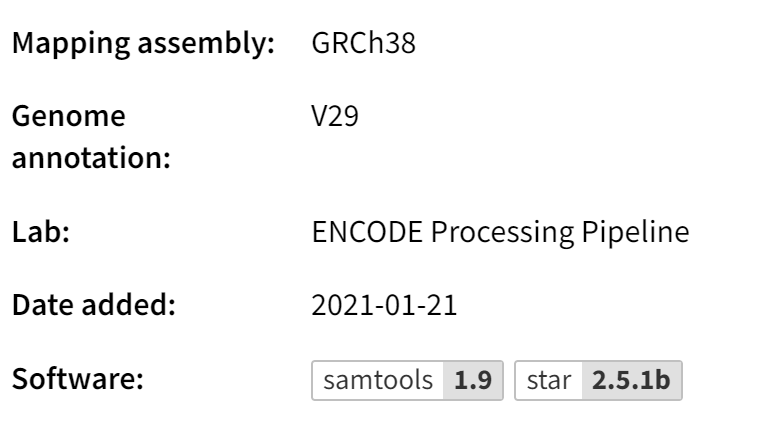

#### `eCLIP` for `ENCFF210ZRQ`

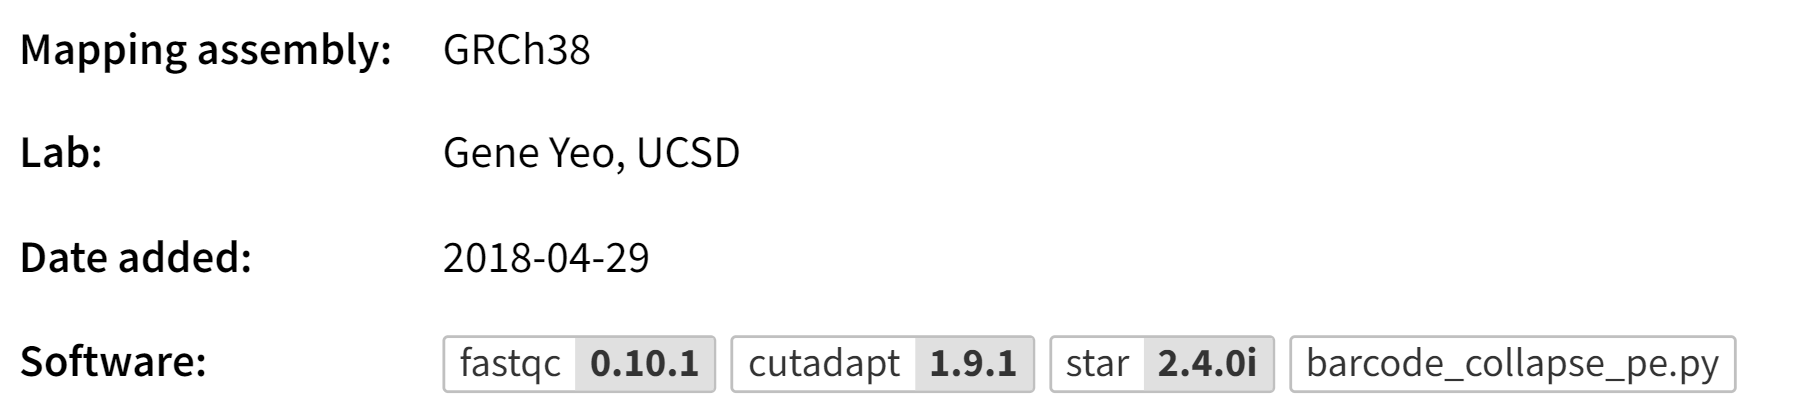

## Are there `eCLIP` experiments that are missing targets in `shRNA`?

Yes, there are 31 RBPs that have `eCLIP` but no `shRNA Knockdown`. 

Interestingly, after some cursory looking, it seems many but not all have `CRISPR RNA-Seq` instead. 

In [18]:
eclip_targets = eclip["Experiment target"].unique().tolist()
len(eclip_targets)

eclip_targets

168

['FUS-human',
 'ZNF800-human',
 'DDX52-human',
 'BCLAF1-human',
 'EXOSC5-human',
 'SDAD1-human',
 'NIP7-human',
 'HLTF-human',
 'AQR-human',
 'CPEB4-human',
 'PHF6-human',
 'G3BP1-human',
 'SAFB-human',
 'STAU2-human',
 'DDX51-human',
 'ZC3H8-human',
 'PUM1-human',
 'AATF-human',
 'FXR2-human',
 'SUPV3L1-human',
 'DDX1-human',
 'NSUN2-human',
 'MBNL1-human',
 'TARDBP-human',
 'MORC2-human',
 'RPS10-human',
 'SSB-human',
 'ABCF1-human',
 'DDX21-human',
 'AKAP1-human',
 'UPF1-human',
 'WDR43-human',
 'PRPF4-human',
 'TIAL1-human',
 'GRWD1-human',
 'PCBP1-human',
 'KHSRP-human',
 'HNRNPC-human',
 'EIF3G-human',
 'FTO-human',
 'MATR3-human',
 'UTP18-human',
 'ELAVL1-human',
 'RPS6-human',
 'GARS-human',
 'APEX1-human',
 'FMR1-human',
 'RYBP-human',
 'FUBP3-human',
 'CPSF6-human',
 'U2AF2-human',
 'NOL12-human',
 'ADAT1-human',
 'HNRNPA1-human',
 'NOLC1-human',
 'NONO-human',
 'YWHAG-human',
 'SND1-human',
 'DHX30-human',
 'LARP4-human',
 'FASTKD2-human',
 'XRN2-human',
 'SF3B4-human',
 'SR

In [19]:
shrna_targets = shrna["Experiment target"].unique().tolist()
len(shrna_targets)

shrna_targets

256

['MARK2-human',
 nan,
 'PRPF4-human',
 'FUBP1-human',
 'NUP35-human',
 'XPO1-human',
 'ABT1-human',
 'EWSR1-human',
 'SSRP1-human',
 'HNRNPL-human',
 'TRIP6-human',
 'CCAR2-human',
 'SRPK2-human',
 'RPS2-human',
 'PA2G4-human',
 'PSIP1-human',
 'SF1-human',
 'HSPD1-human',
 'CSTF2-human',
 'RBM3-human',
 'DDX6-human',
 'FKBP4-human',
 'PUS1-human',
 'UPF2-human',
 'EFTUD2-human',
 'SLBP-human',
 'FAM120A-human',
 'PNPT1-human',
 'RPS19-human',
 'U2AF1-human',
 'XPO5-human',
 'MAK16-human',
 'MBNL1-human',
 'KHSRP-human',
 'MAGOH-human',
 'TARDBP-human',
 'RBM25-human',
 'EIF4A3-human',
 'ASCC1-human',
 'CELF1-human',
 'FASTKD2-human',
 'CSTF2T-human',
 'AGO1-human',
 'RECQL-human',
 'EXOSC9-human',
 'GTF2F1-human',
 'PABPC4-human',
 'FXR2-human',
 'SRSF1-human',
 'AKAP1-human',
 'TAF15-human',
 'DDX55-human',
 'BUD13-human',
 'PUM2-human',
 'CPSF6-human',
 'SUPT6H-human',
 'RBM39-human',
 'AKAP8-human',
 'YBX3-human',
 'SAFB2-human',
 'RBM22-human',
 'KHDRBS1-human',
 'CCDC124-human',


In [20]:
tmp = []
for rbp in eclip_targets: 
    if rbp not in shrna_targets: 
        tmp.append(rbp)

In [21]:
len(tmp)
tmp

31

['ZNF800-human',
 'EXOSC5-human',
 'SDAD1-human',
 'SAFB-human',
 'STAU2-human',
 'MORC2-human',
 'ELAVL1-human',
 'RPS6-human',
 'GARS-human',
 'APEX1-human',
 'RYBP-human',
 'ADAT1-human',
 'NOLC1-human',
 'ZC3H11A-human',
 'IGF2BP1-human',
 'EIF3H-human',
 'NIPBL-human',
 'RPS11-human',
 'RBM5-human',
 'GNL3-human',
 'METTL1-human',
 'ELAC2-human',
 'DGCR8-human',
 'DDX43-human',
 'EXOSC10-human',
 'RPS3-human',
 'EIF4E-human',
 'SRSF7-human',
 'DDX42-human',
 'RNF187-human',
 'CDC40-human']